<a href="https://colab.research.google.com/github/snehakodavanti-droid5/AIML---Training/blob/main/AIML_Training_Program_Module_3_project_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Student Training Program on AIML**
# Project : Data Visualization, Choosing K-value and Appreciating Feature Scaling and Standardization

---

## Binary Classification Task: Diabetes Dataset

We'll be using ML techniques learnt uptil now to predict whether a Pima Indian Woman has diabetes or not, based on information about the patient such as blood pressure, body mass index (BMI), age, etc.

**Dataset Source:** [Pima Indians Diabetes Database](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)


# Introduction

Scientists carried out a study to investigate the significance of health-related predictors of diabetes in **Pima Indian Women**. The study population was females (21 years and above) of Pima Indian heritage.

The purpose of the study was to find out the factors that are associated with the presence of diabetes in Pima Indians.

To find out the reason behind this, we have to first analyze the relationship between different features, such as the number of times a woman was pregnant, their BMI, prevalence of diabetes, etc.

## Exploratory Data Analysis (EDA) and Statistical Analysis

## Import Libraries

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.set_style('darkgrid')

import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

Upload the diabetes.csv file that has been provided to you.

In [64]:
# Upload the diabetes data CSV file
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes (1).csv


In [65]:
# Load the dataset
diabetes_data = pd.read_csv('diabetes.csv')


## Dataset Overview

In [66]:
# Display the first few rows
diabetes_data.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.000000,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.000000,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.000000,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.000000,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.000000,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.000000,29.0,125.0,25.6,0.201,30,0
6,3,78.0,50.000000,32.0,88.0,31.0,0.248,26,1
7,10,115.0,72.405184,29.0,125.0,35.3,0.134,29,0
8,2,197.0,70.000000,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.000000,29.0,125.0,32.3,0.232,54,1


In [67]:
# Check dataset dimensions
print(f"Dataset shape: {diabetes_data.shape}")
print(f"Number of samples: {diabetes_data.shape[0]}")
print(f"Number of features: {diabetes_data.shape[1]}")
print(f"Total values in dataset: {diabetes_data.size}")

Dataset shape: (768, 9)
Number of samples: 768
Number of features: 9
Total values in dataset: 6912


Observation:The dataset contains 768 samples and 9 columns. The columns include several medical features and one target variable indicating diabetes outcome.

In [68]:
# Dataset information
diabetes_data.info()

diabetes_data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies          

In [69]:
# Check for missing values
print("Missing values per column:")
print(diabetes_data.isnull().sum())

print("\nPercentage of missing values:")
print((diabetes_data.isnull().sum() / len(diabetes_data)) * 100)

Missing values per column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Percentage of missing values:
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64


## Statistical Summary

In [70]:
# Descriptive statistics
diabetes_data.describe(percentiles=[0.25, 0.5, 0.75, 0.95])

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.435949,12.096346,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.202592,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
95%,10.000000,181.000000,90.000000,44.000000,293.000000,44.395000,1.132850,58.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [71]:
# Check the target variable distribution
print("Outcome distribution:")
print(diabetes_data['Outcome'].value_counts())
print(f"\nPercentage of diabetic cases: {diabetes_data['Outcome'].mean()*100:.2f}%")

print("\nOutcome Percentage Distribution:")
print(diabetes_data['Outcome'].value_counts(normalize=True) * 100)

Outcome distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage of diabetic cases: 34.90%

Outcome Percentage Distribution:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


## Data Visualization

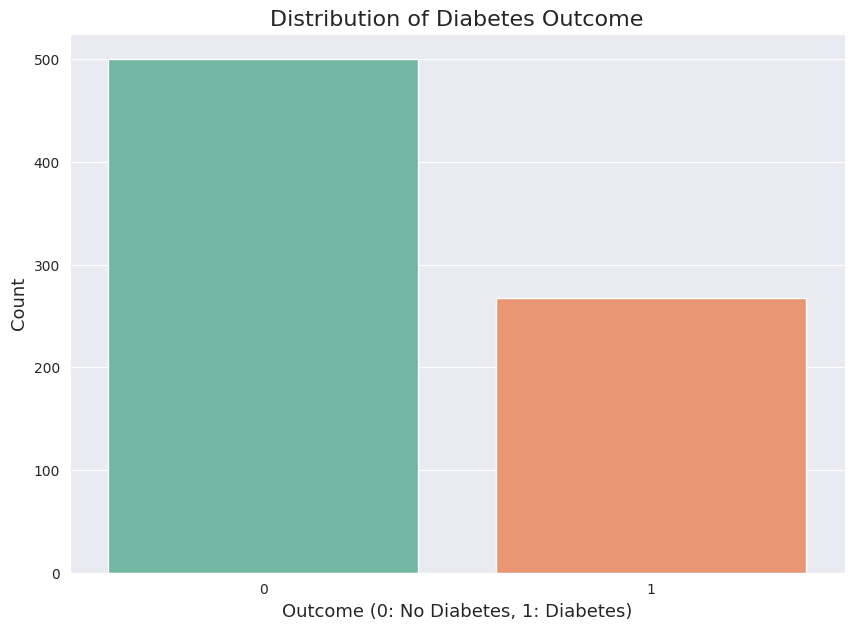

In [72]:
# Visualize the target variable distribution
plt.figure(figsize=(10,7))
sns.countplot(x='Outcome', data=diabetes_data, palette='Set2')
plt.title('Distribution of Diabetes Outcome', fontsize=16)
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

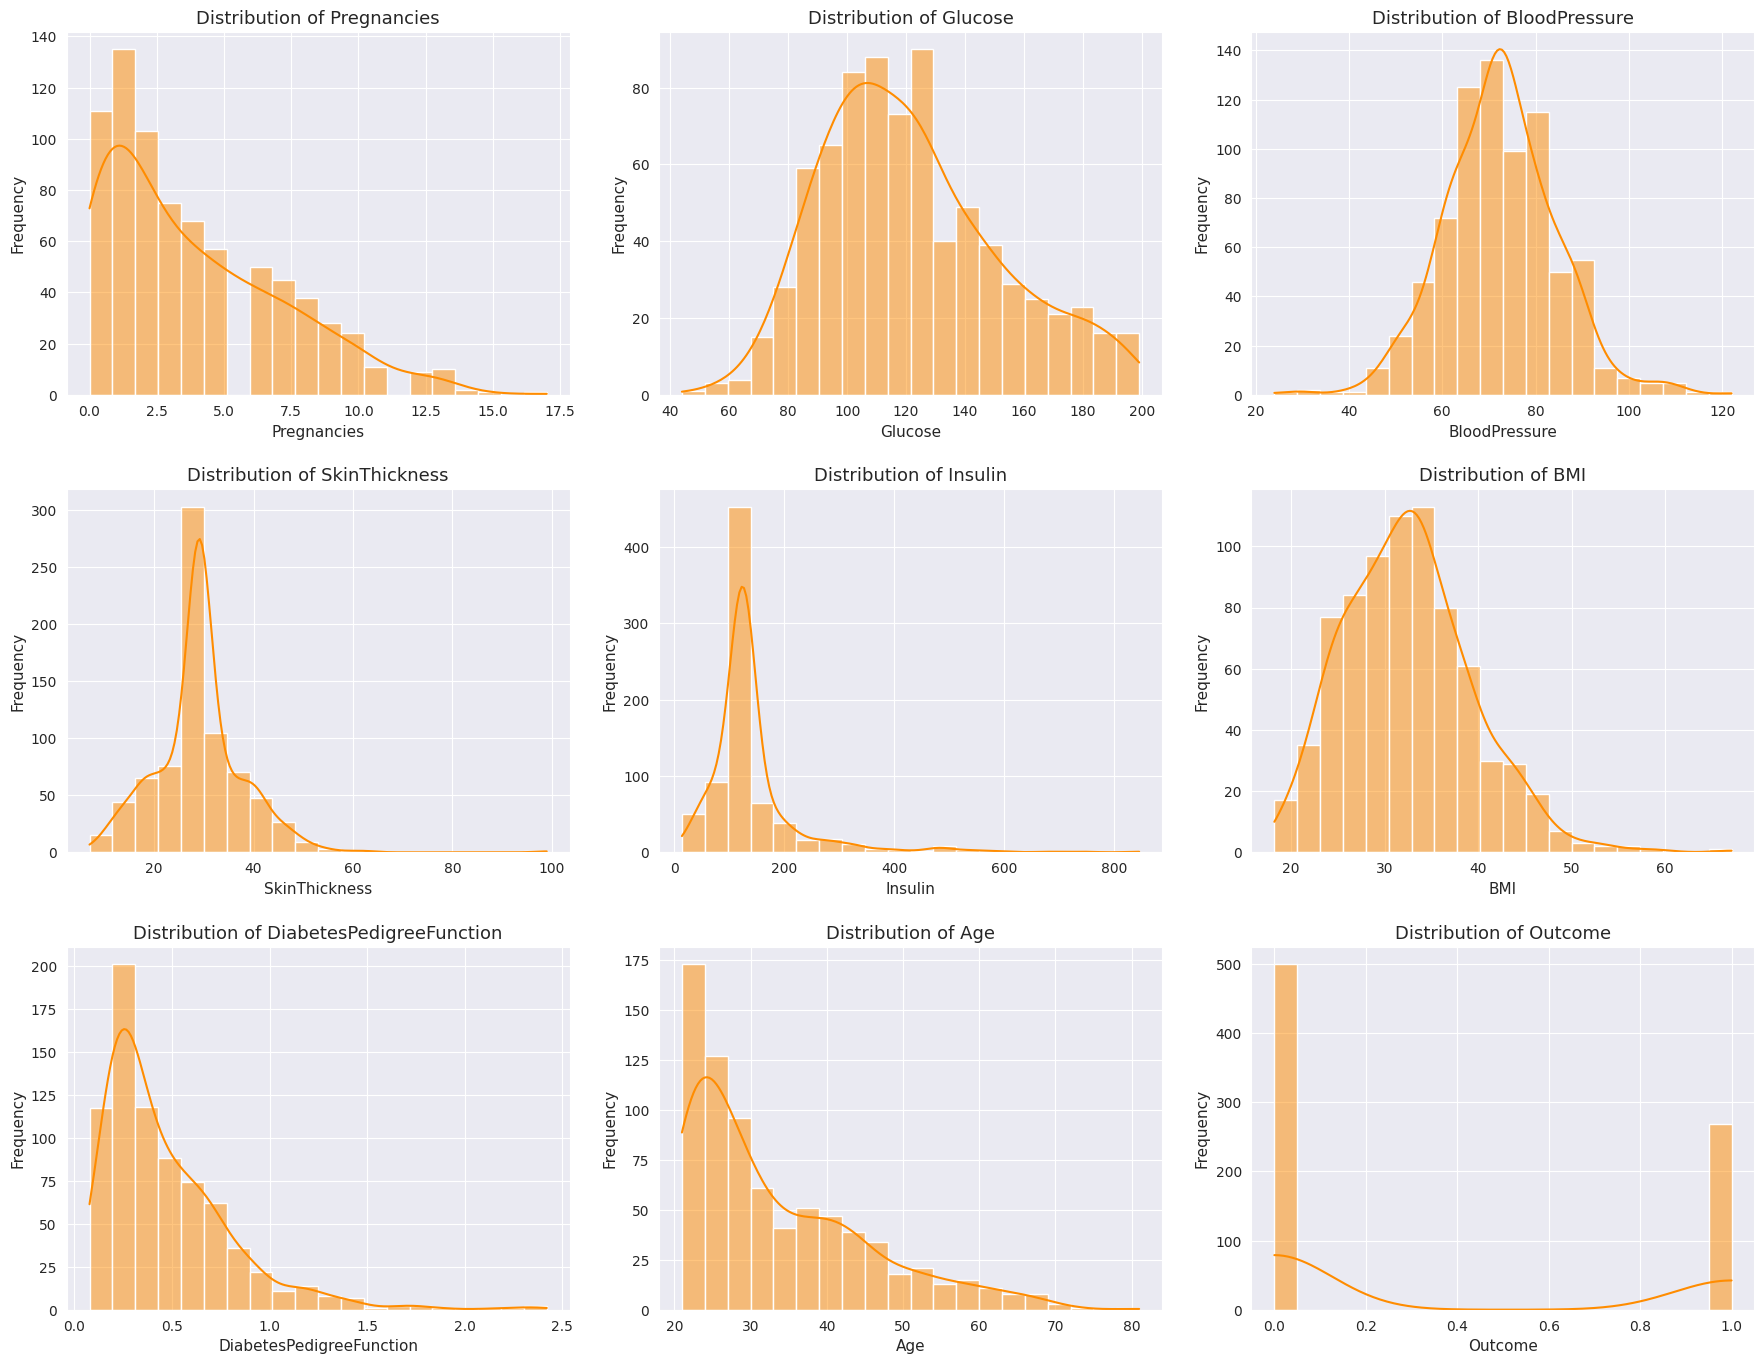

In [73]:
# Distribution of all features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(diabetes_data.columns):
    sns.histplot(diabetes_data[col], kde=True, bins=20, ax=axes[i], color='darkorange')
    axes[i].set_title(f'Distribution of {col}', fontsize=13)
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Frequency', fontsize=11)

plt.tight_layout(pad=2.0)
plt.show()

## TASK-1: Correlation Analysis

Compute the correlation matrix and visualize it using a heatmap to understand the relationships between different features.

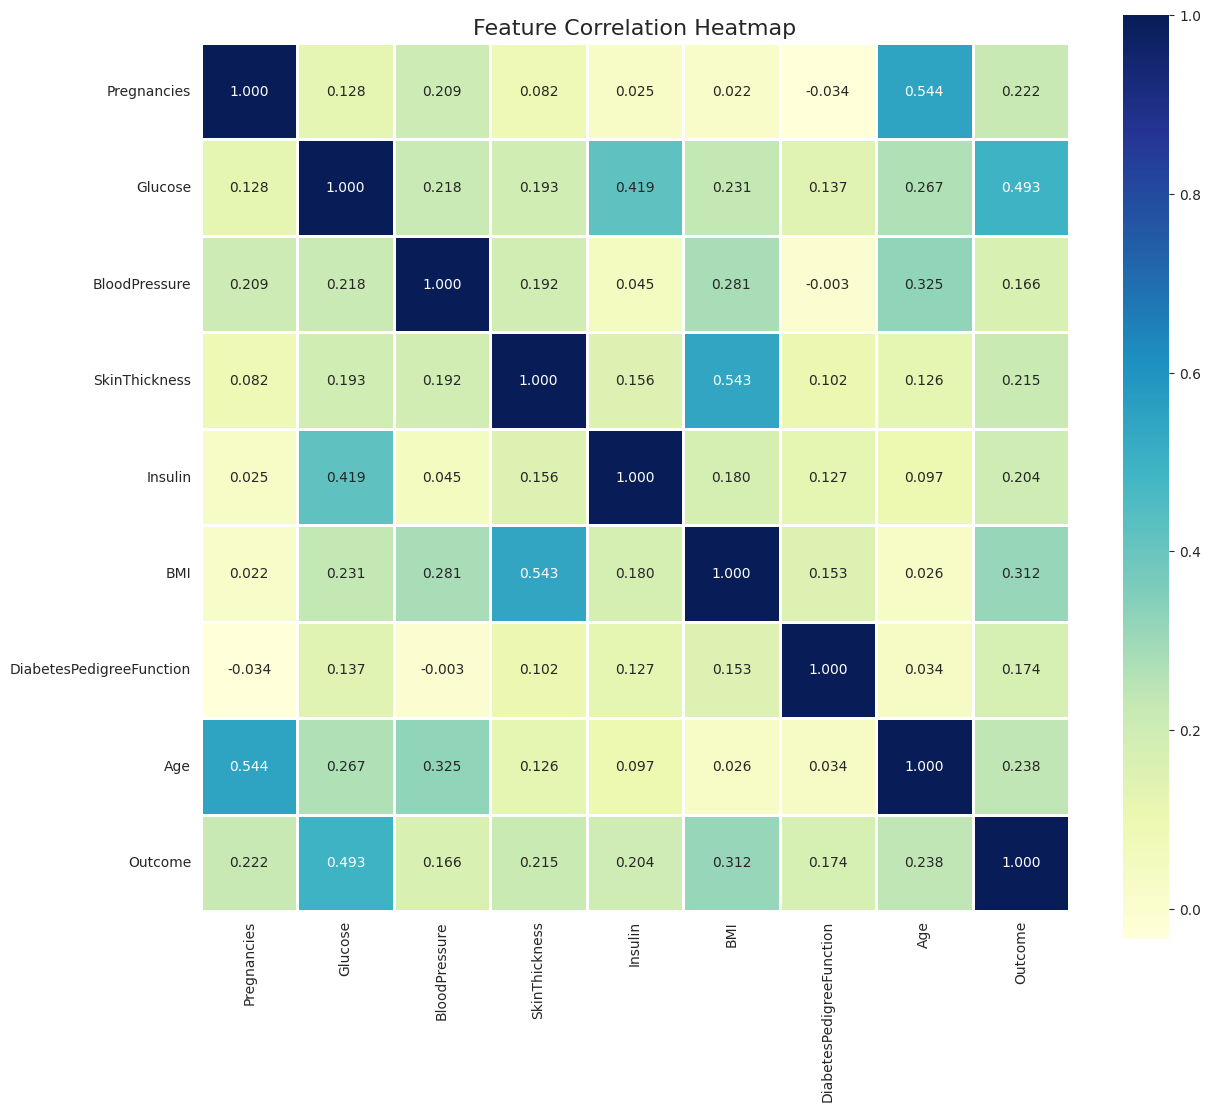

In [74]:
# Calculate correlation matrix
correlation_matrix = diabetes_data.corr()

# Visualize with heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='YlGnBu', fmt='.3f', linewidths=1 , square=True)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

## TASK-2: Comparative Box Plots

Create box plots to compare the distribution of each feature for diabetic vs non-diabetic patients.

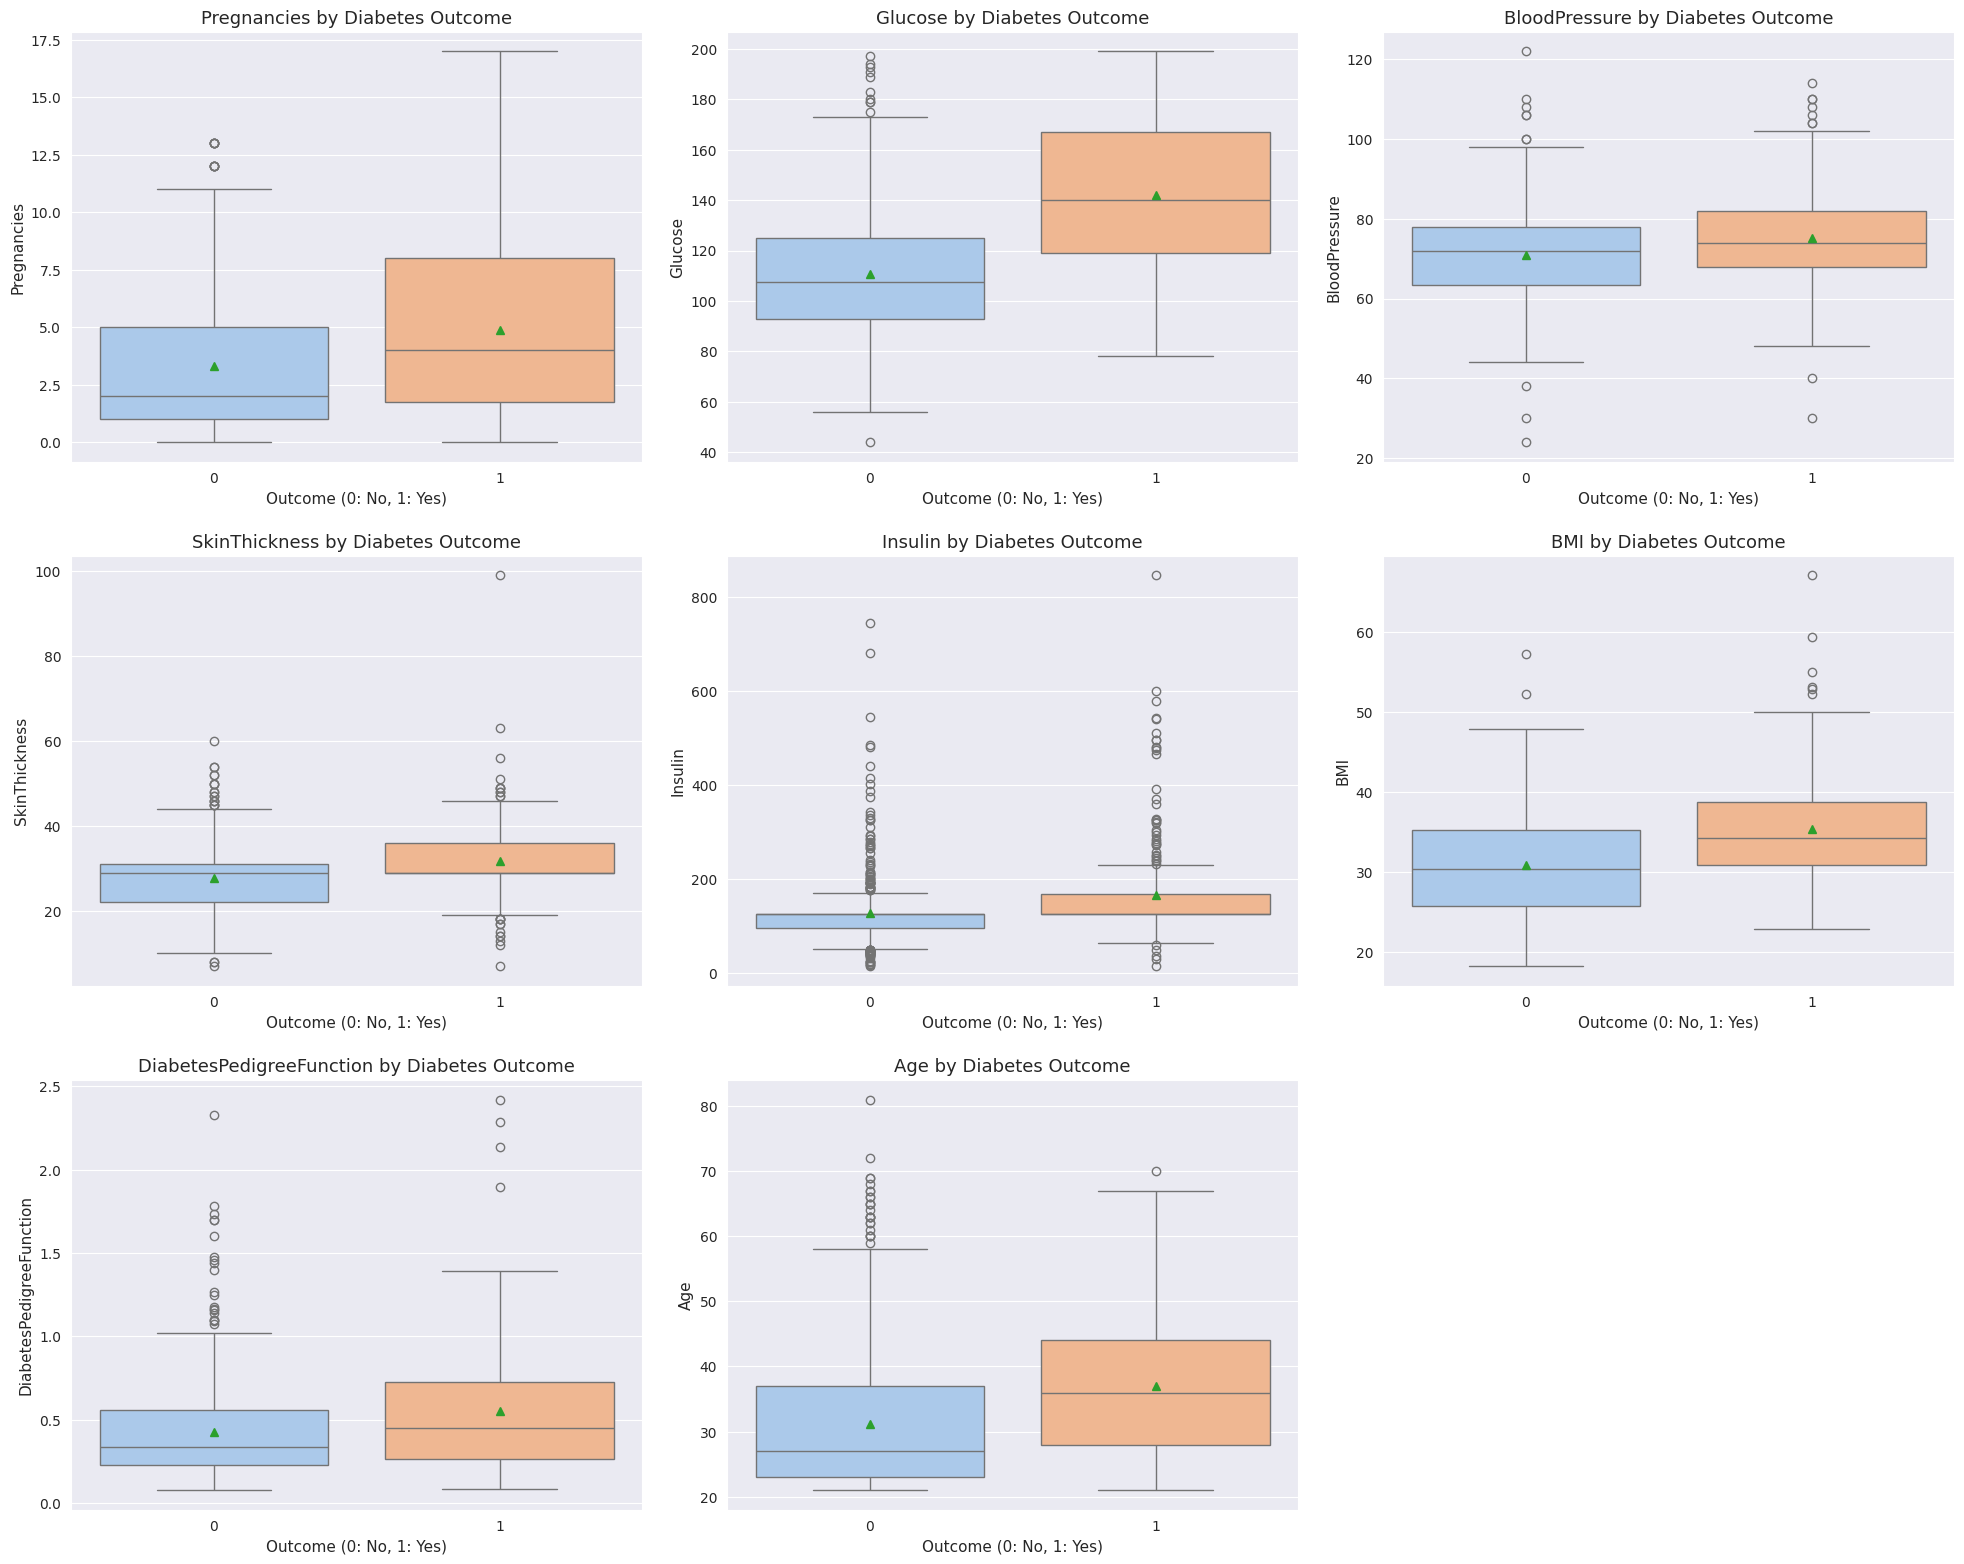

In [75]:
# Box plots for all features grouped by Outcome
fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

feature_cols = diabetes_data.columns[:-1]  # All columns except Outcome

for i, col in enumerate(feature_cols):
    sns.boxplot(x='Outcome', y=col, data=diabetes_data, ax=axes[i], palette='pastel',showmeans=True)
    axes[i].set_title(f'{col} by Diabetes Outcome', fontsize=13)
    axes[i].set_xlabel('Outcome (0: No, 1: Yes)', fontsize=11)
    axes[i].set_ylabel(col, fontsize=11)

# Hide the last subplot if not needed
axes[-1].axis('off')

plt.tight_layout(pad=2.0)
plt.show()

## TASK-3: Pairplot Analysis

Create a pairplot to visualize the pairwise relationships between features, colored by the Outcome variable.

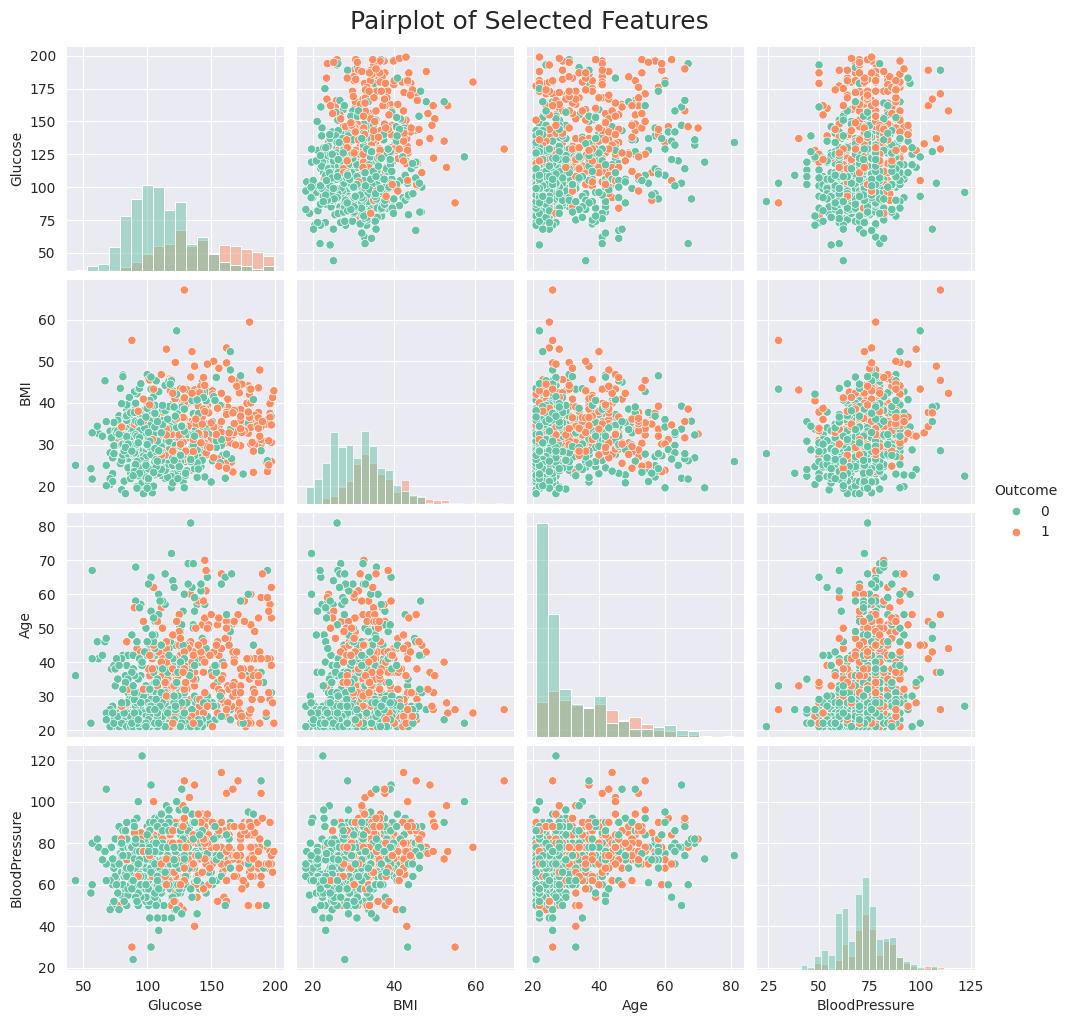

In [103]:
# Select a subset of features for clearer visualization
selected_features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Outcome']
sns.pairplot(diabetes_data[selected_features], hue='Outcome', palette='Set2', diag_kind='hist', height=2.5)
plt.suptitle('Pairplot of Selected Features', y=1.02, fontsize=18)
plt.show()

## K-Nearest Neighbors (KNN) Classification

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

## TASK-4: Train-Test Split

Split the dataset into training (70%) and testing (30%) sets.

In [78]:
# Prepare features and target
X = diabetes_data.drop('Outcome', axis=1)
y = diabetes_data['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42,stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 576
Testing set size: 192


## TASK-5: Build and Evaluate KNN Model

Train a KNN classifier with k=1 and evaluate its performance.

In [79]:
# Train KNN with k=1
knn = KNeighborsClassifier(n_neighbors=1,weights='distance')
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred)*100:.2f}%")

Confusion Matrix:
[[95 30]
 [31 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.76      0.76       125
           1       0.55      0.54      0.54        67

    accuracy                           0.68       192
   macro avg       0.65      0.65      0.65       192
weighted avg       0.68      0.68      0.68       192


Accuracy Score: 68.23%


## TASK-6: Finding the Optimal K Value

Test different values of K (from 1 to 40) and plot the error rate to find the optimal K value.

In [80]:
# Store the original unscaled data for later comparison
unchanged_data = X.copy()

# Function to evaluate KNN performance across different K values
def plot_KNN_error_rate(xdata, ydata):
    error_rate = []
    test_scores = []
    train_scores = []

    X_train, X_test, y_train, y_test = train_test_split(xdata, ydata, test_size=0.25, random_state=42)

    for i in range(1, 40):
        knn = KNeighborsClassifier(n_neighbors=i,weights='distance')
        knn.fit(X_train, y_train)
        pred_i = knn.predict(X_test)

        error_rate.append(np.mean(pred_i != y_test))
        train_scores.append(knn.score(X_train, y_train))
        test_scores.append(knn.score(X_test, y_test))

    # Plot error rate
    plt.figure(figsize=(14, 8))
    plt.plot(range(1, 40), error_rate, color='green', linestyle='dashed', marker='s',
             markerfacecolor='orange', markersize=7)
    plt.title('Error Rate vs. K Value', fontsize=16)
    plt.xlabel('K', fontsize=13)
    plt.ylabel('Error Rate', fontsize=13)
    plt.grid(True, alpha=0.5)
    plt.show()

    # Find best K values
    max_train_score = max(train_scores)
    train_scores_ind = [i for i, v in enumerate(train_scores) if v == max_train_score]
    print(f'Max train score: {max_train_score*100:.2f}% at K = {[x+1 for x in train_scores_ind]}')

    max_test_score = max(test_scores)
    test_scores_ind = [i for i, v in enumerate(test_scores) if v == max_test_score]
    print(f'Max test score: {max_test_score*100:.2f}% at K = {[x+1 for x in test_scores_ind]}')

    return test_scores

Performance on Unscaled Data:


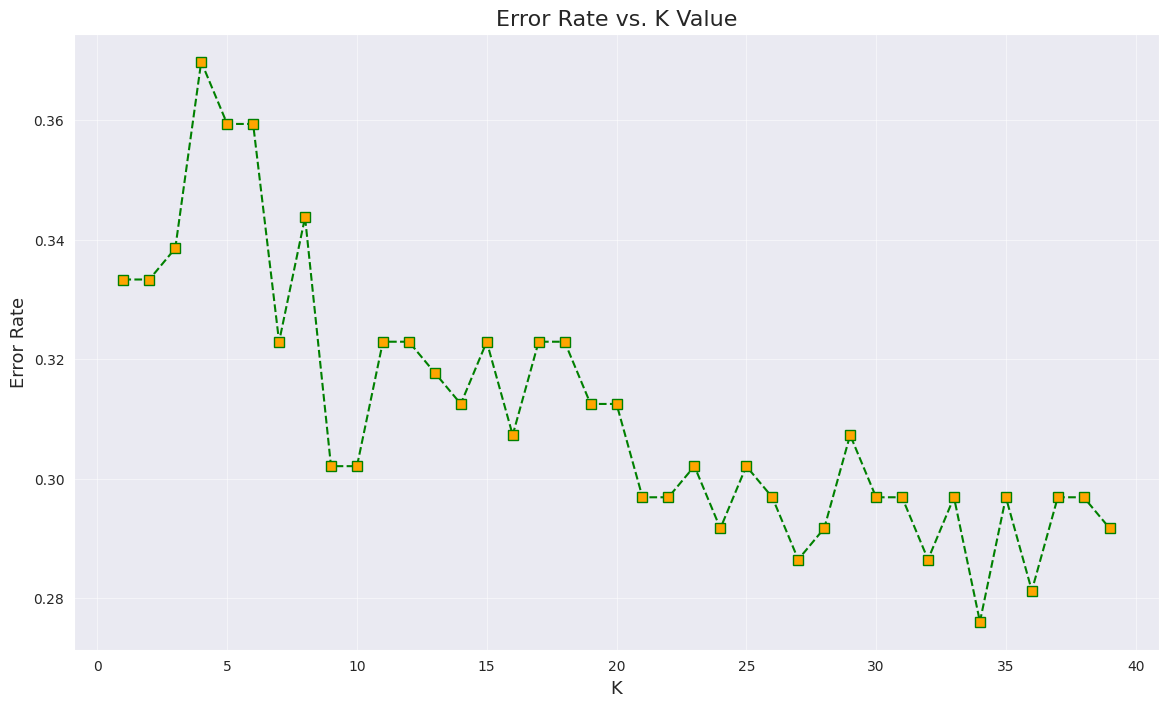

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 72.40% at K = [34]


In [81]:
# Evaluate on unscaled data
print("Performance on Unscaled Data:")
unchanged_test_scores = plot_KNN_error_rate(unchanged_data, y)

## Standardize the Variables

Standardization (also called z-score normalization) is the process of putting different variables on the same scale. Standardization transforms your data such that the resulting distribution has a mean of 0 and a standard deviation of 1.

$$ Z = {X - \mu \over \sigma}$$

Where:
- Z is the standardized value
- X is the original value
- μ is the mean of the feature
- σ is the standard deviation of the feature

In [82]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Initialize the scaler
scaler = MinMaxScaler()

# Fit the scaler on training data features
scaler.fit(diabetes_data.drop('Outcome', axis=1))

# Transform the features
scaled_data = scaler.transform(diabetes_data.drop('Outcome', axis=1))

In [83]:
# Create a dataframe with scaled features
df_feat = pd.DataFrame(scaled_data, columns=diabetes_data.columns[:-1])
df_feat.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.352941,0.670968,0.489796,0.304348,0.133413,0.314928,0.234415,0.483333
1,0.058824,0.264516,0.428571,0.239130,0.133413,0.171779,0.116567,0.166667
2,0.470588,0.896774,0.408163,0.239130,0.133413,0.104294,0.253629,0.183333
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000
5,0.294118,0.464516,0.510204,0.239130,0.133413,0.151329,0.052519,0.150000
6,0.176471,0.219355,0.265306,0.271739,0.088942,0.261759,0.072588,0.083333
7,0.588235,0.458065,0.493930,0.239130,0.133413,0.349693,0.023911,0.133333
8,0.117647,0.987097,0.469388,0.413043,0.635817,0.251534,0.034159,0.533333
9,0.470588,0.522581,0.734694,0.239130,0.133413,0.288344,0.065756,0.550000


In [84]:
# Verify standardization: mean should be ~0, std should be ~1
print("Mean of scaled features:")
print(df_feat.mean())
print("\nStandard deviation of scaled features:")
print(df_feat.std())

print("\nMinimum values:")
print(df_feat.min())
print("\nMaximum values:")
print(df_feat.max())

Mean of scaled features:
Pregnancies                 0.226180
Glucose                     0.501205
BloodPressure               0.493930
SkinThickness               0.240305
Insulin                     0.152250
BMI                         0.291518
DiabetesPedigreeFunction    0.168179
Age                         0.204015
dtype: float64

Standard deviation of scaled features:
Pregnancies                 0.198210
Glucose                     0.196361
BloodPressure               0.123432
SkinThickness               0.095557
Insulin                     0.103826
BMI                         0.140597
DiabetesPedigreeFunction    0.141473
Age                         0.196004
dtype: float64

Minimum values:
Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
dtype: float64

Maximum values:
Pregnanc

Performance on Standardized Data:


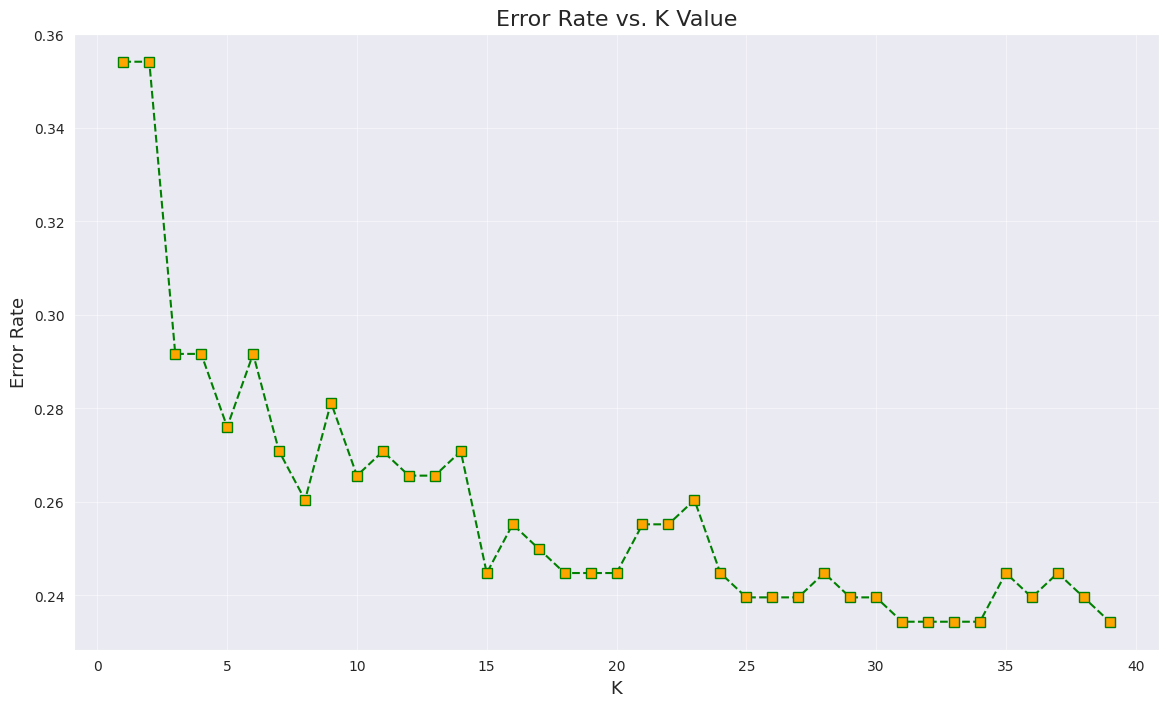

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 76.56% at K = [31, 32, 33, 34, 39]


In [85]:
# Evaluate on scaled data
print("Performance on Standardized Data:")
scaled_test_scores = plot_KNN_error_rate(scaled_data, y)

## Comparing Accuracy Before and After Standardization

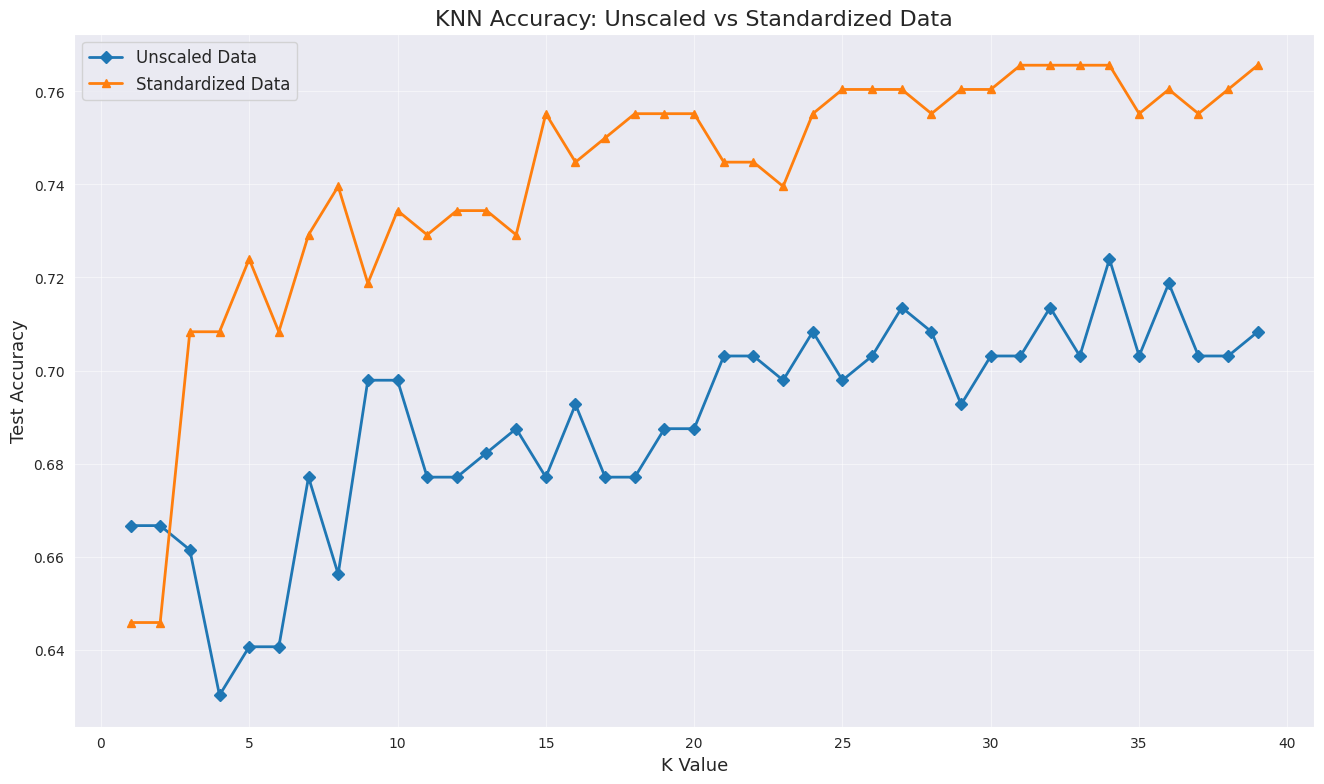

In [86]:
# Compare performance
plt.figure(figsize=(16, 9))
plt.plot(range(1, 40), unchanged_test_scores, marker='D', label='Unscaled Data', linewidth=2)
plt.plot(range(1, 40), scaled_test_scores, marker='^', label='Standardized Data', linewidth=2)
plt.title('KNN Accuracy: Unscaled vs Standardized Data', fontsize=16)
plt.xlabel('K Value', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# Conclusion

From the data analysis we carried out, it seems that there is some form of an association between BMI, number of pregnancies, glucose levels, and the test results for diabetes.

As for the classification tasks, the standardized data yields much better results than the unscaled data over most of the K-values considered, thus indicating the importance of standardizing data in Machine Learning problems. This improvement occurs because:

1. KNN is distance-based and features with larger scales dominate the distance calculation
2. Standardization puts all features on equal footing
3. This leads to more balanced and accurate predictions

---
# DIY Challenges

Test your understanding by completing these three challenges. Solutions are not provided - work through them independently!

## Challenge 1: MinMax Scaling Comparison

**Objective:** Implement MinMax scaling and compare its performance with StandardScaler.

**Tasks:**
1. Import `MinMaxScaler` from sklearn.preprocessing
2. Apply MinMax scaling to the dataset (scales features to range [0, 1])
3. Use the `plot_KNN_error_rate()` function on the MinMax-scaled data
4. Create a comparison plot showing all three approaches: unscaled, standardized, and MinMax-scaled
5. Analyze which scaling method performs best and why

**Hint:** MinMaxScaler formula is: $X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$

In [87]:
# Your code here for Challenge 1
from sklearn.preprocessing import MinMaxScaler
minmax_scaler = MinMaxScaler()
minmax_scaled_data = minmax_scaler.fit_transform(diabetes_data.drop('Outcome', axis=1))

Performance on MinMax Scaled Data:


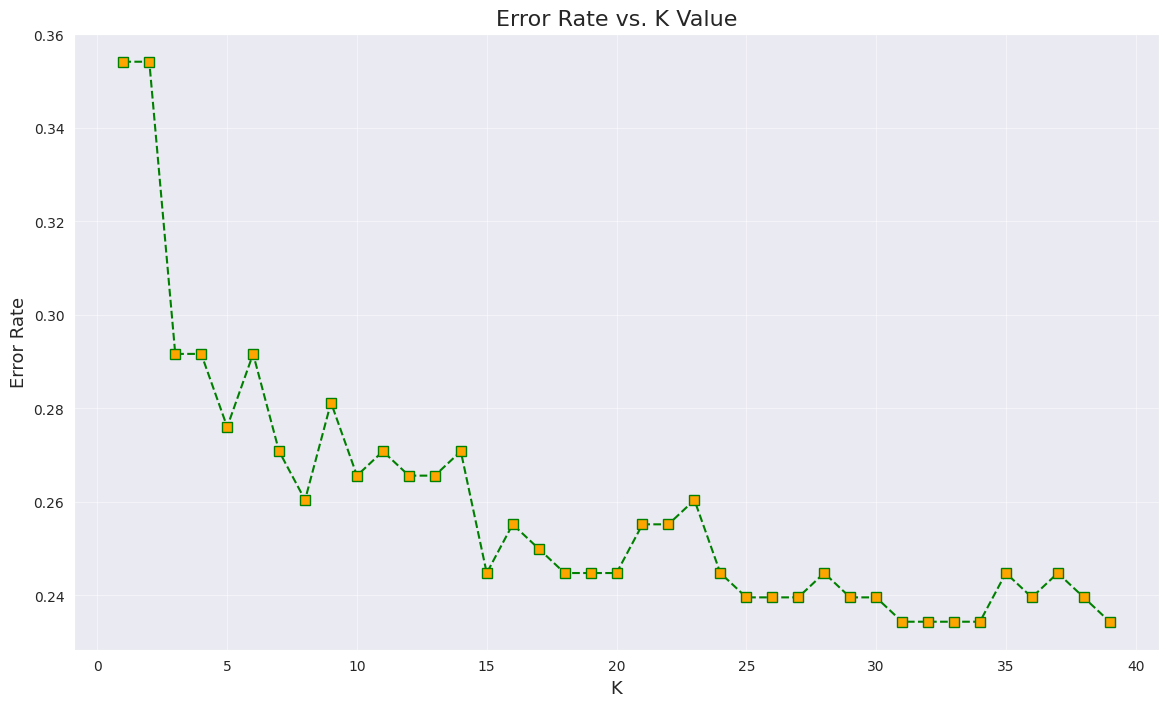

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 76.56% at K = [31, 32, 33, 34, 39]


In [88]:
print("Performance on MinMax Scaled Data:")
minmax_test_scores = plot_KNN_error_rate(minmax_scaled_data,diabetes_data['Outcome'])

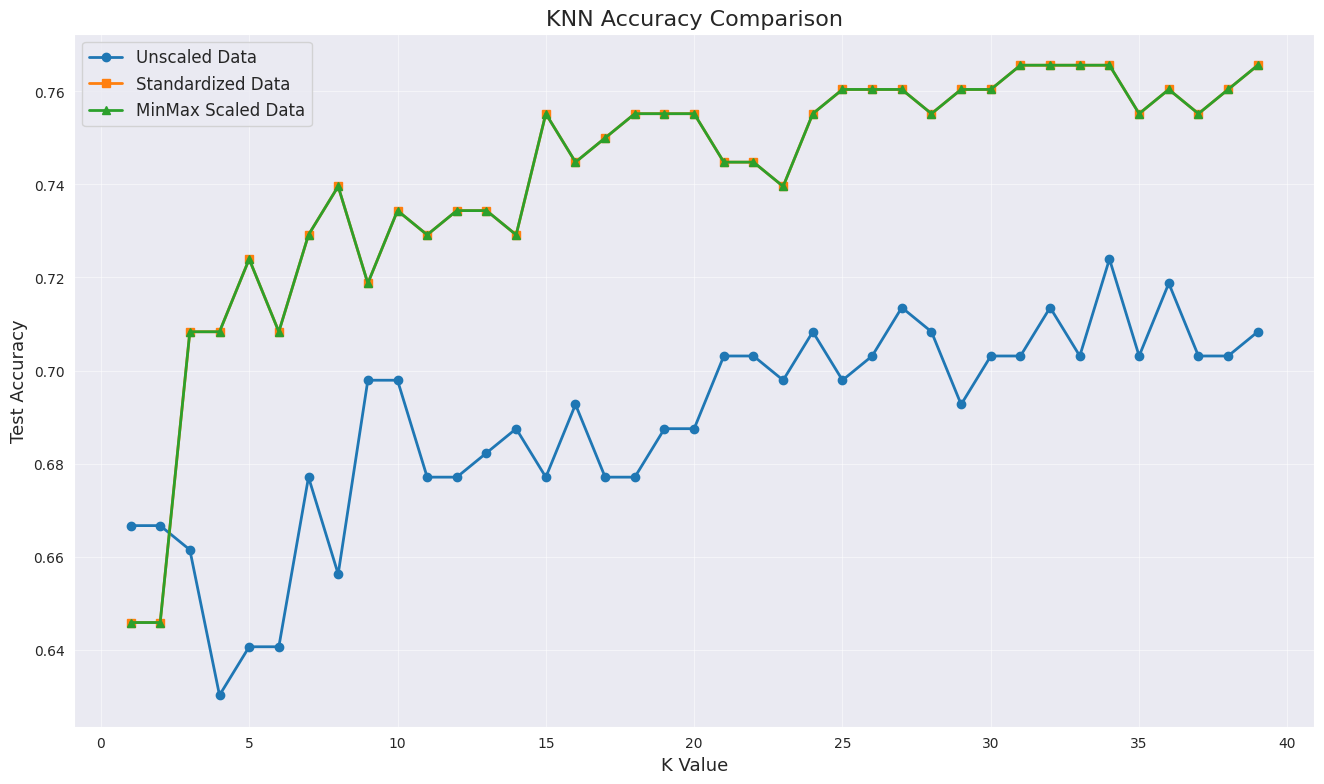

In [89]:
plt.figure(figsize=(16, 9))
plt.plot(range(1, 40),unchanged_test_scores,marker='o',label='Unscaled Data',linewidth=2)
plt.plot(range(1, 40),scaled_test_scores,marker='s',label='Standardized Data',linewidth=2)
plt.plot(range(1, 40),minmax_test_scores,marker='^',label='MinMax Scaled Data',linewidth=2)

plt.title('KNN Accuracy Comparison', fontsize=16)
plt.xlabel('K Value', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

Analysis:

1. Unscaled data may perform worse because features have different ranges.
2. StandardScaler transforms features to mean 0 and standard deviation 1.
3. MinMaxScaler transforms features to the range [0,1].
4. KNN relies on distance calculations, so feature scaling is important.
5. The scaling method with the highest test accuracy is considered the best for this dataset.

## Challenge 2: K-Fold Cross-Validation Analysis

**Objective:** Implement K-Fold cross-validation to get more robust performance estimates.

**Tasks:**
1. Import `cross_val_score` from sklearn.model_selection
2. Implement 5-fold cross-validation for KNN with K values from 1 to 40
3. Compare cross-validation scores for:
   - Unscaled data
   - Standardized data
   - MinMax-scaled data (from Challenge 1)
4. Plot the mean cross-validation accuracy with standard deviation error bars
5. Determine the optimal K value for each scaling approach

**Bonus:** Calculate and display the standard deviation of cross-validation scores to understand model stability.

In [90]:
# Your code here for Challenge 2
from sklearn.model_selection import cross_val_score

In [91]:
def plot_cv_scores(xdata, ydata):
    mean_scores = []
    std_scores = []
    for k in range(1, 41):
        knn = KNeighborsClassifier(n_neighbors=k)
        scores = cross_val_score(knn,xdata,ydata,cv=5,scoring='accuracy')
        mean_scores.append(scores.mean())
        std_scores.append(scores.std())
    return mean_scores, std_scores

In [92]:
unscaled_mean_scores, unscaled_std_scores = plot_cv_scores(unchanged_data,diabetes_data['Outcome'])

standardized_mean_scores, standardized_std_scores = plot_cv_scores(scaled_data,diabetes_data['Outcome'])

minmax_mean_scores, minmax_std_scores = plot_cv_scores(minmax_scaled_data,diabetes_data['Outcome'])

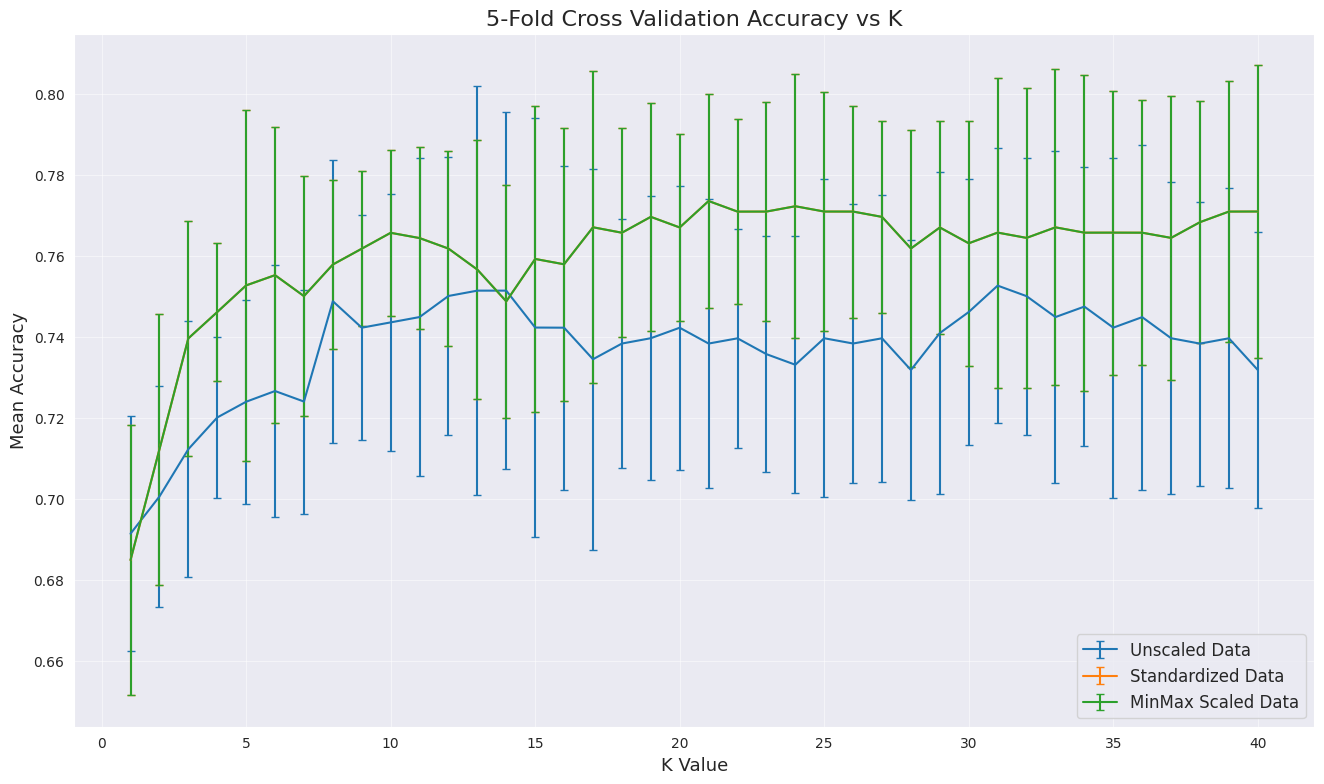

In [93]:
plt.figure(figsize=(16, 9))
plt.errorbar(range(1, 41),unscaled_mean_scores,yerr=unscaled_std_scores,label='Unscaled Data',capsize=3)
plt.errorbar(range(1, 41),standardized_mean_scores,yerr=standardized_std_scores,label='Standardized Data',capsize=3)
plt.errorbar(range(1, 41),minmax_mean_scores,yerr=minmax_std_scores,label='MinMax Scaled Data',capsize=3)

plt.title('5-Fold Cross Validation Accuracy vs K', fontsize=16)
plt.xlabel('K Value', fontsize=13)
plt.ylabel('Mean Accuracy', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

In [94]:
best_unscaled_k = np.argmax(unscaled_mean_scores) + 1
best_standardized_k = np.argmax(standardized_mean_scores) + 1
best_minmax_k = np.argmax(minmax_mean_scores) + 1

print("Best K for Unscaled Data:", best_unscaled_k)
print("Best Accuracy:", max(unscaled_mean_scores))
print("\nBest K for Standardized Data:", best_standardized_k)
print("Best Accuracy:", max(standardized_mean_scores))
print("\nBest K for MinMax Data:", best_minmax_k)
print("Best Accuracy:", max(minmax_mean_scores))

Best K for Unscaled Data: 31
Best Accuracy: 0.7526440879382056

Best K for Standardized Data: 21
Best Accuracy: 0.7735166793990323

Best K for MinMax Data: 21
Best Accuracy: 0.7735166793990323


In [95]:
print("Model Stability Analysis")
print("\nUnscaled Data")
print("Lowest Std Dev:", min(unscaled_std_scores))
print("Highest Std Dev:", max(unscaled_std_scores))
print("\nStandardized Data")
print("Lowest Std Dev:", min(standardized_std_scores))
print("Highest Std Dev:", max(standardized_std_scores))
print("\nMinMax Data")
print("Lowest Std Dev:", min(minmax_std_scores))
print("Highest Std Dev:", max(minmax_std_scores))

Model Stability Analysis

Unscaled Data
Lowest Std Dev: 0.019796604541175947
Highest Std Dev: 0.0516914881236518

Standardized Data
Lowest Std Dev: 0.017025275790414445
Highest Std Dev: 0.04323936710753682

MinMax Data
Lowest Std Dev: 0.017025275790414445
Highest Std Dev: 0.04323936710753682


## Challenge 3: Feature Selection and Performance Analysis

**Objective:** Investigate how feature selection impacts KNN performance.

**Tasks:**
1. Based on the correlation analysis from TASK-1, identify the top 4 features most correlated with 'Outcome'
2. Create a reduced dataset with only these 4 features
3. Apply standardization to this reduced feature set
4. Train KNN models (K from 1 to 40) on both:
   - Full feature set (standardized)
   - Reduced feature set (standardized)
5. Create a comparison plot showing:
   - Accuracy vs K for full features
   - Accuracy vs K for reduced features
6. Analyze:
   - Does reducing features improve or hurt performance?
   - What is the optimal K for each feature set?
   - What insights can you draw about feature importance?

**Bonus:** Try different numbers of features (3, 5, 6) and see how it affects performance.

In [96]:
# Your code here for Challenge 3
correlation_with_outcome = diabetes_data.corr()['Outcome'].abs()
top_features = correlation_with_outcome.sort_values(ascending=False).index[1:5]
print("Top 4 Features:")
print(top_features)

X_reduced = diabetes_data[top_features]
print("Reduced Dataset Shape:")
print(X_reduced.shape)

Top 4 Features:
Index(['Glucose', 'BMI', 'Age', 'Pregnancies'], dtype='object')
Reduced Dataset Shape:
(768, 4)


In [97]:
from sklearn.preprocessing import StandardScaler
reduced_scaler = StandardScaler()
X_reduced_scaled = reduced_scaler.fit_transform(X_reduced)

Performance on Reduced Feature Set:


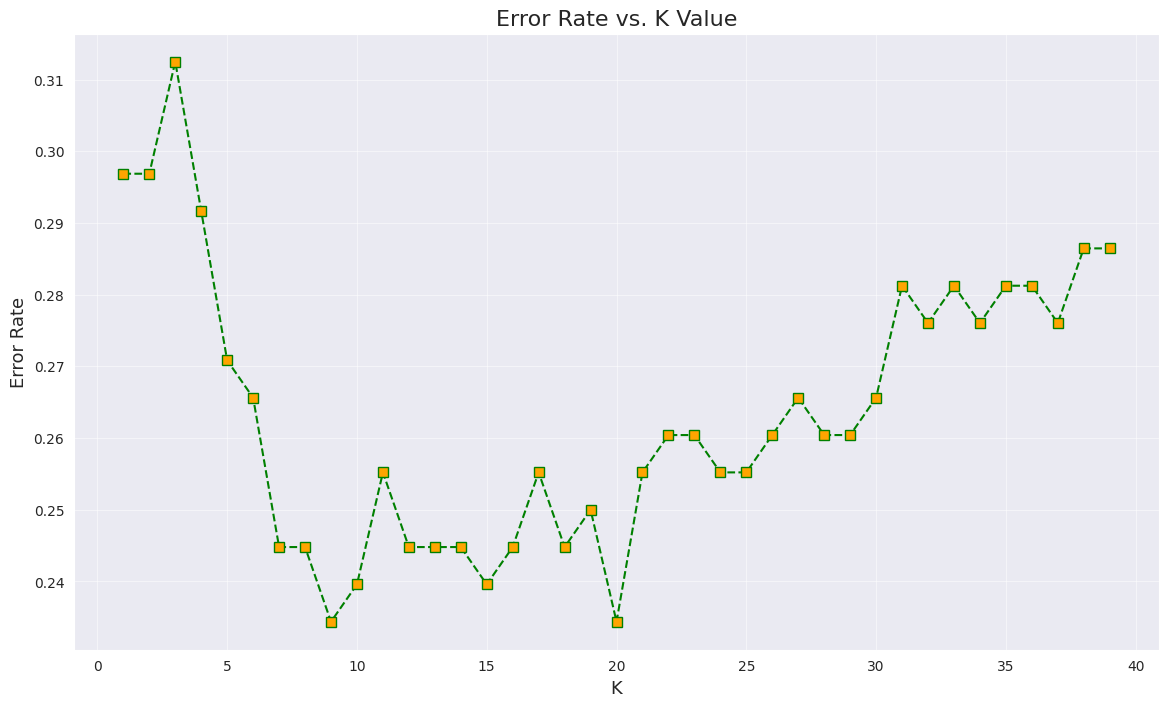

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 76.56% at K = [9, 20]


In [98]:
print("Performance on Reduced Feature Set:")
reduced_test_scores = plot_KNN_error_rate(X_reduced_scaled,diabetes_data['Outcome'])

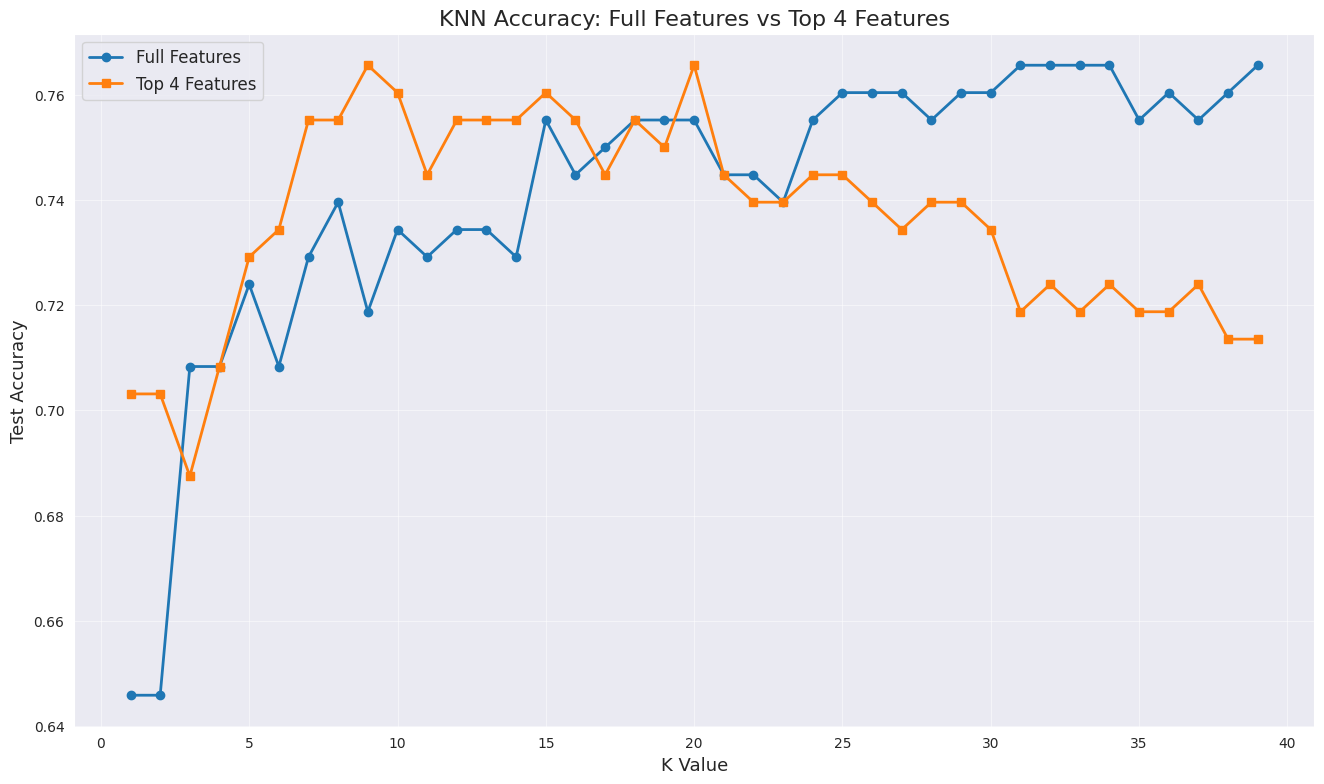

In [99]:
plt.figure(figsize=(16, 9))
plt.plot(range(1, 40),scaled_test_scores,marker='o',label='Full Features',linewidth=2)
plt.plot(range(1, 40),reduced_test_scores,marker='s',label='Top 4 Features',linewidth=2)
plt.title('KNN Accuracy: Full Features vs Top 4 Features', fontsize=16)
plt.xlabel('K Value', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

In [100]:
best_k_full = np.argmax(scaled_test_scores) + 1
best_k_reduced = np.argmax(reduced_test_scores) + 1

print("Optimal K for Full Features:", best_k_full)
print("Best Accuracy:", max(scaled_test_scores))

print("\nOptimal K for Top 4 Features:", best_k_reduced)
print("Best Accuracy:", max(reduced_test_scores))

Optimal K for Full Features: 31
Best Accuracy: 0.765625

Optimal K for Top 4 Features: 9
Best Accuracy: 0.765625


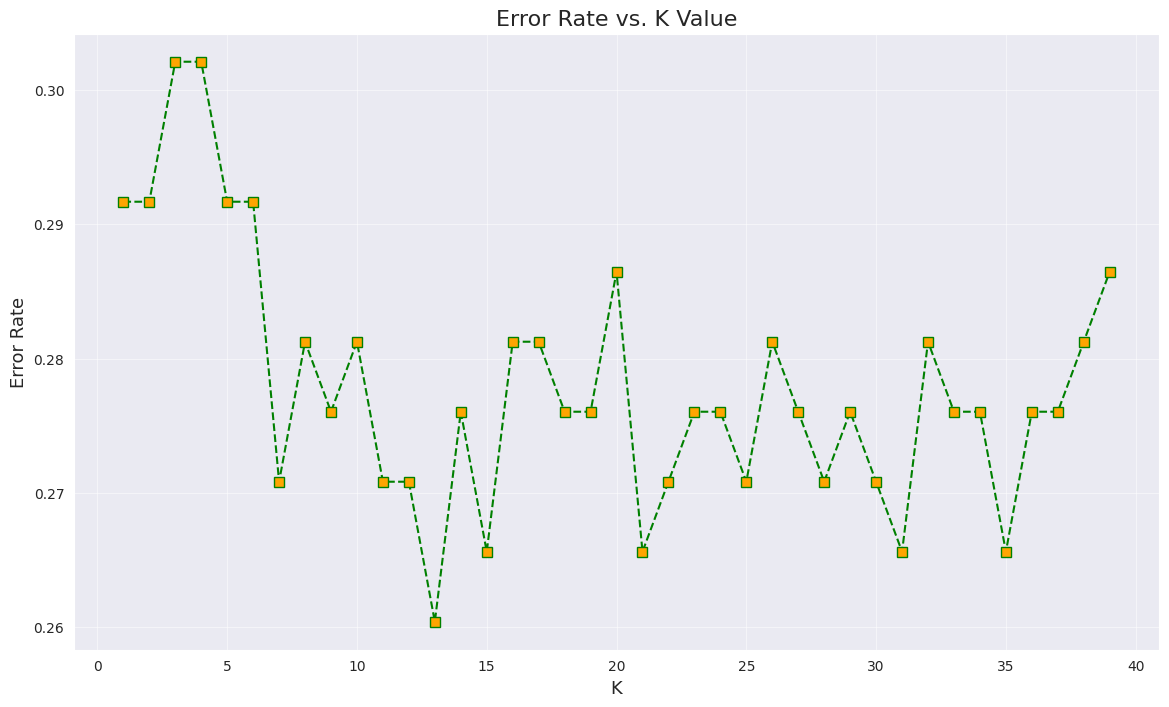

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 73.96% at K = [13]


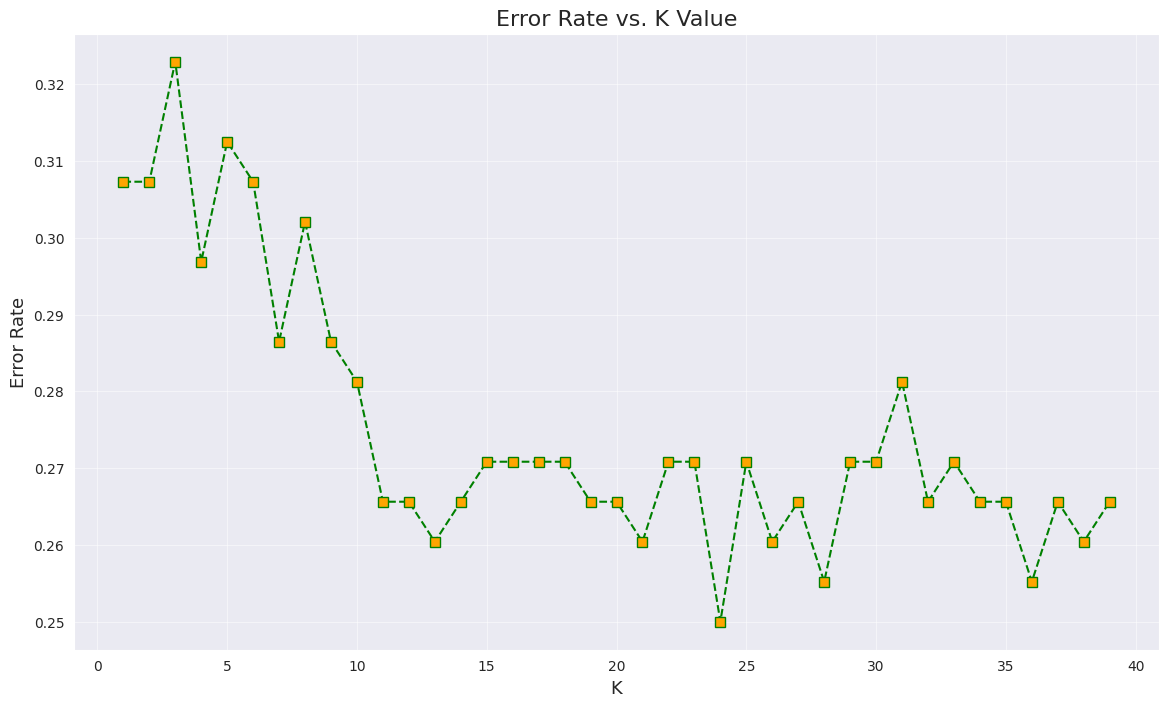

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 75.00% at K = [24]


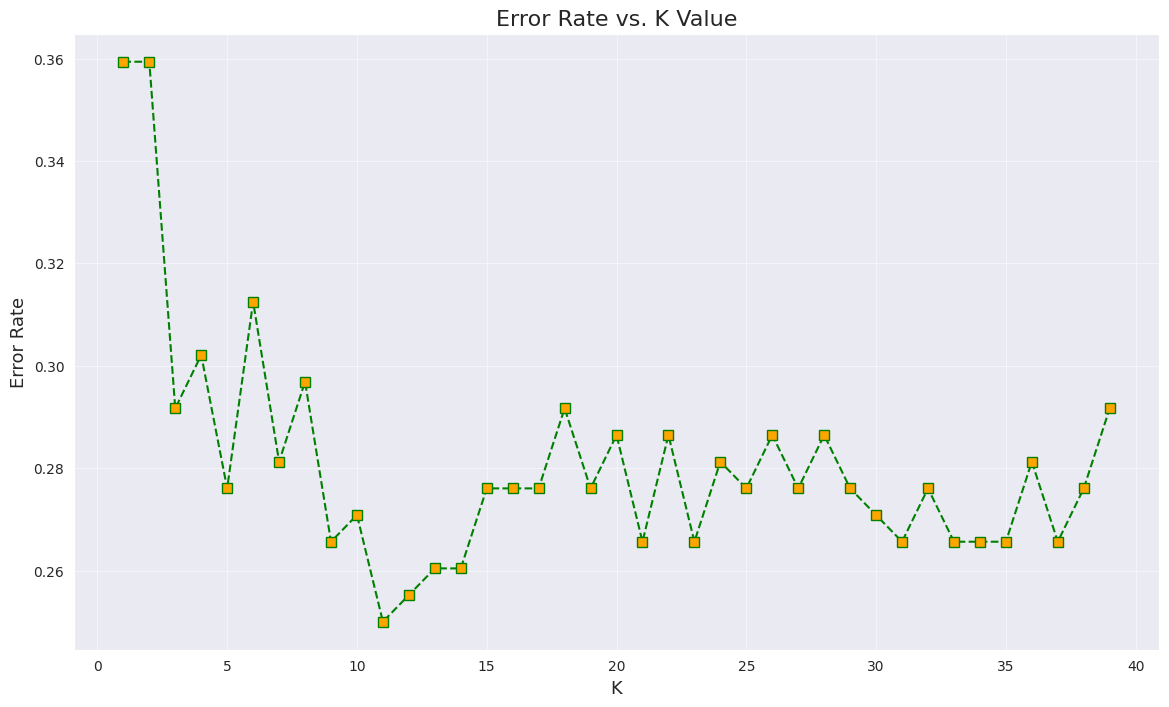

Max train score: 100.00% at K = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Max test score: 75.00% at K = [11]


In [101]:
#3 features
top3_features = correlation_with_outcome.sort_values(ascending=False).index[1:4]
X_top3 = diabetes_data[top3_features]
X_top3_scaled = StandardScaler().fit_transform(X_top3)
top3_scores = plot_KNN_error_rate(X_top3_scaled,diabetes_data['Outcome'])

#5 features
top5_features = correlation_with_outcome.sort_values(ascending=False).index[1:6]
X_top5 = diabetes_data[top5_features]
X_top5_scaled = StandardScaler().fit_transform(X_top5)
top5_scores = plot_KNN_error_rate(X_top5_scaled,diabetes_data['Outcome'])

#6 features
top6_features = correlation_with_outcome.sort_values(ascending=False).index[1:7]
X_top6 = diabetes_data[top6_features]
X_top6_scaled = StandardScaler().fit_transform(X_top6)
top6_scores = plot_KNN_error_rate(X_top6_scaled,diabetes_data['Outcome'])

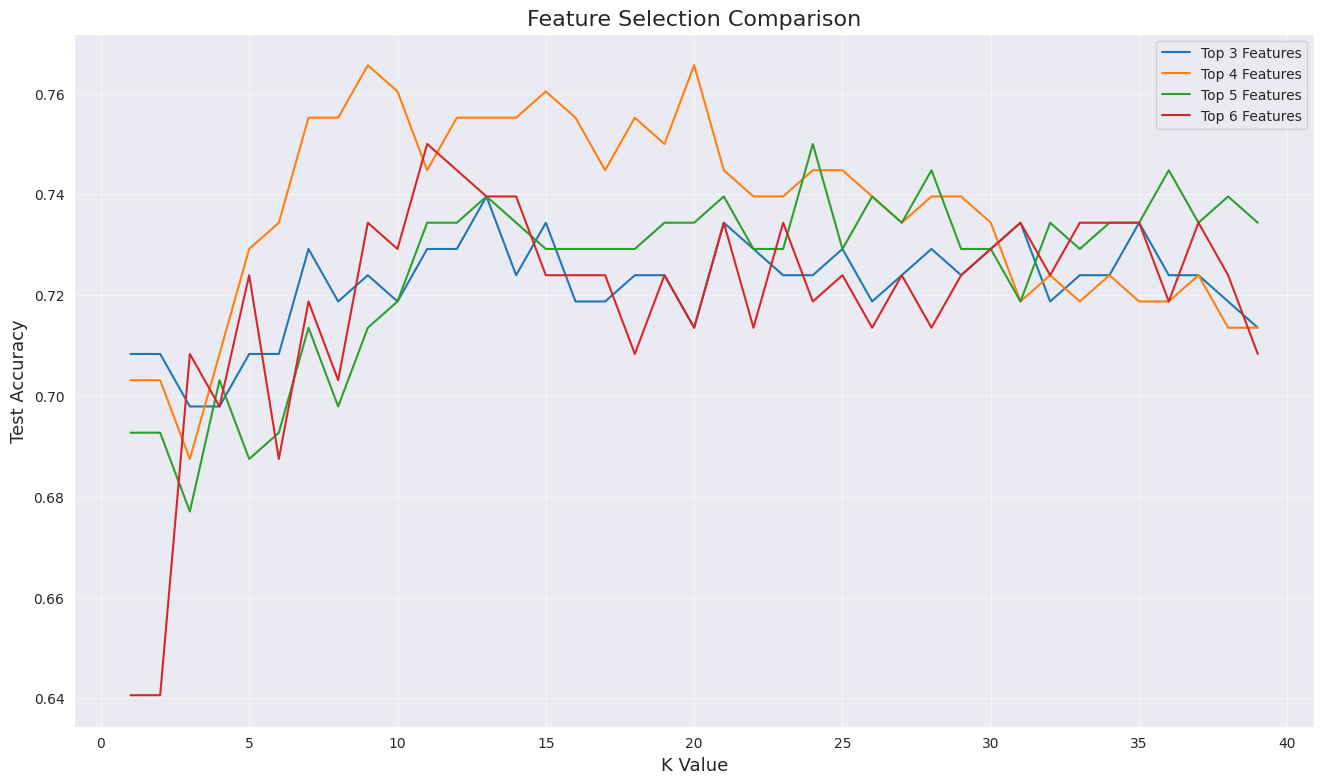

In [102]:
#comparision

plt.figure(figsize=(16, 9))
plt.plot(range(1, 40), top3_scores, label='Top 3 Features')
plt.plot(range(1, 40), reduced_test_scores, label='Top 4 Features')
plt.plot(range(1, 40), top5_scores, label='Top 5 Features')
plt.plot(range(1, 40), top6_scores, label='Top 6 Features')
plt.title('Feature Selection Comparison', fontsize=16)
plt.xlabel('K Value', fontsize=13)
plt.ylabel('Test Accuracy', fontsize=13)
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

Feature Selection Analysis
1. Removing less important features can reduce noise.
2. Too few features may lose useful information.
3. The feature set with the highest accuracy provides the best balance.
4. Features with stronger correlation to Outcome generally contribute more to prediction.
5. Comparing Top 3, Top 4, Top 5 and Top 6 features helps identify the optimal feature subset.


---
# References

1. [Pima Indians Diabetes Database - Kaggle](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)
2. [Scikit-learn Documentation - KNN Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
3. [Scikit-learn Documentation - StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
4. [Scikit-learn Documentation - MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)